# BGMI Player Data Analysis and Cleaning using Python

This project focuses on understanding, cleaning, analyzing, and visualizing a BGMI player dataset using Python.

The project is divided into the following phases:

• Phase 1 – Dataset Understanding
• Phase 2 – Data Cleaning
• Feature Engineering
• Phase 3 – Data Analysis
• Phase 4 – Data Visualization
• Phase 5 – Conclusion

In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)

players = [f"Player_{i}" for i in range(1, 1001)]

bgmi = pd.DataFrame({
    "Player_ID": np.arange(1, 1001),
    "Player_Name": players,
    "Level": np.random.randint(1, 101, 1000),
    "Matches_Played": np.random.randint(50, 5000, 1000),
    "Wins": np.random.randint(0, 1500, 1000),
    "Kills": np.random.randint(100, 15000, 1000),
    "Damage": np.random.randint(10000, 800000, 1000),
    "Headshots": np.random.randint(50, 5000, 1000),
    "KD": np.round(np.random.uniform(0.5, 8.0, 1000), 2),
    "Rank": np.random.choice(
        ["Bronze", "Silver", "Gold", "Platinum", "Diamond", "Crown", "Ace", "Conqueror"],
        1000
    ),
    "Mode": np.random.choice(
        ["Solo", "Duo", "Squad"],
        1000
    ),
    "Map": np.random.choice(
        ["Erangel", "Miramar", "Sanhok", "Livik", "Nusa"],
        1000
    ),
    "Clan": np.random.choice(
        ["Alpha", "Phoenix", "Legends", "Warriors", "Titans", "Ghost"],
        1000
    ),
    "UC_Spent": np.random.randint(0, 10001, 1000),
    "Premium_Pass": np.random.choice([True, False], 1000)
})

print(bgmi.head())
print(bgmi.shape)

   Player_ID Player_Name  Level  Matches_Played  Wins  Kills  Damage  \
0          1    Player_1     52            4768  1216   3964  783221   
1          2    Player_2     93            4057   310  10231  570897   
2          3    Player_3     15            2522  1142  13317  184037   
3          4    Player_4     72            2710  1241   7933  673376   
4          5    Player_5     61            2789   426  11361  442995   

   Headshots    KD      Rank   Mode     Map      Clan  UC_Spent  Premium_Pass  
0       2690  4.07   Diamond  Squad   Livik   Legends       480          True  
1       3851  2.89     Crown  Squad    Nusa   Legends      5263         False  
2       2611  4.17  Platinum    Duo   Livik     Alpha      4094          True  
3       3299  6.95     Crown   Solo  Sanhok    Titans      6167         False  
4        420  4.94  Platinum    Duo    Nusa  Warriors      2793         False  
(1000, 15)


# 📌 Phase 1 – Dataset Understanding

Before performing any cleaning or analysis, it is important to understand the dataset. In this phase, we examine the structure of the data, identify the available columns, check the number of records, and review the data types. This helps us understand what information is available and prepares the dataset for the next steps.

### What are the first five records of the BGMI dataset?

In [17]:
bgmi.head()

,Player_ID,Player_Name,Level,Matches_Played,Wins,Kills,Damage,Headshots,KD,Rank,Mode,Map,Clan,UC_Spent,Premium_Pass
0,1,Player_1,52,4768,1216,3964,783221,2690,4.07,Diamond,Squad,Livik,Legends,480,True
1,2,Player_2,93,4057,310,10231,570897,3851,2.89,Crown,Squad,Nusa,Legends,5263,False
2,3,Player_3,15,2522,1142,13317,184037,2611,4.17,Platinum,Duo,Livik,Alpha,4094,True
3,4,Player_4,72,2710,1241,7933,673376,3299,6.95,Crown,Solo,Sanhok,Titans,6167,False
4,5,Player_5,61,2789,426,11361,442995,420,4.94,Platinum,Duo,Nusa,Warriors,2793,False


### Observation

The first five rows provide an overview of the dataset. They include player information such as level, matches played, kills, damage, rank, map, clan, and premium pass details.

### Insight

Viewing the first few rows helps us understand the structure of the dataset before performing any operations.

### What is the size of the BGMI dataset?

In [6]:
bgmi.shape

(1000, 15)

### Observation

The dataset contains 1000 rows and 15 columns.

### Insight

Knowing the size of the dataset helps estimate the amount of information available for analysis.

### What are the names of all columns in the BGMI dataset?

In [7]:
bgmi.columns

Index(['Player_ID', 'Player_Name', 'Level', 'Matches_Played', 'Wins', 'Kills',
       'Damage', 'Headshots', 'KD', 'Rank', 'Mode', 'Map', 'Clan', 'UC_Spent',
       'Premium_Pass'],
      dtype='str')

### Observation

The dataset contains columns related to player information, gameplay statistics, rank, map, clan, and premium features.

### Insight

Understanding the available columns helps identify which features can be cleaned and analyzed later.

### What are the data types of each column?

In [21]:
bgmi.dtypes

Player_ID           int64
Player_Name           str
Level               int32
Matches_Played      int32
Wins                int32
Kills               int32
Damage              int32
Headshots           int32
KD                float64
Rank                  str
Mode                  str
Map                   str
Clan                  str
UC_Spent            int32
Premium_Pass         bool
dtype: object

### Observation

The dataset contains different data types such as integer (`int64`), decimal (`float64`), text (`object`), and boolean (`bool`). Each column has an appropriate data type based on the information it stores.

### Insight

Understanding data types is important because different data types require different cleaning and analysis techniques. It also helps identify whether any column needs to be converted into another data type before further processing.

### Get complete information about the dataset.

In [5]:
bgmi.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Player_ID       1000 non-null   int64  
 1   Player_Name     1000 non-null   str    
 2   Level           1000 non-null   int32  
 3   Matches_Played  1000 non-null   int32  
 4   Wins            1000 non-null   int32  
 5   Kills           1000 non-null   int32  
 6   Damage          1000 non-null   int32  
 7   Headshots       1000 non-null   int32  
 8   KD              1000 non-null   float64
 9   Rank            1000 non-null   str    
 10  Mode            1000 non-null   str    
 11  Map             1000 non-null   str    
 12  Clan            1000 non-null   str    
 13  UC_Spent        1000 non-null   int32  
 14  Premium_Pass    1000 non-null   bool   
dtypes: bool(1), float64(1), int32(7), int64(1), str(5)
memory usage: 114.3 KB


### Observation

The dataset contains 1000 rows and 15 columns with different data types such as integer, float, object, and boolean. It also provides the number of non-null values and memory usage.

### Insight

Understanding the complete dataset information helps identify the structure of the data and whether any columns contain missing values before cleaning.

### What is the statistical summary of numerical columns?

In [22]:
bgmi.describe()

,Player_ID,Level,Matches_Played,Wins,Kills,Damage,Headshots,KD,UC_Spent
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,50.128000,2518.232000,738.512000,7468.865000,408683.845000,2573.057000,4.185410,4959.978000
std,288.819436,29.573505,1418.986434,419.207697,4263.815009,226858.301488,1447.029138,2.138308,2889.473391
min,1.000000,1.000000,51.000000,1.000000,106.000000,12187.000000,61.000000,0.500000,7.000000
25%,250.750000,24.000000,1301.500000,388.250000,3835.750000,220964.000000,1283.500000,2.387500,2413.500000
50%,500.500000,51.000000,2488.000000,721.500000,7355.000000,407315.500000,2602.000000,4.145000,5063.500000
75%,750.250000,75.000000,3713.500000,1093.500000,11205.750000,605258.750000,3856.750000,6.040000,7410.500000
max,1000.000000,100.000000,4994.000000,1496.000000,14995.000000,799177.000000,4997.000000,7.970000,9990.000000


### Observation

The statistical summary shows the count, mean, standard deviation, minimum, maximum, and quartile values of all numerical columns.

### Insight

These statistics help understand the distribution of numerical data and detect unusual values before analysis.

### How many missing values are present in each column?

In [23]:
bgmi.isnull().sum()

Player_ID         0
Player_Name       0
Level             0
Matches_Played    0
Wins              0
Kills             0
Damage            0
Headshots         0
KD                0
Rank              0
Mode              0
Map               0
Clan              0
UC_Spent          0
Premium_Pass      0
dtype: int64

### Observation

No missing values were found in any column of the dataset.

### Insight

Since the dataset has no missing values, no additional data cleaning is required for null values.

### Are there any duplicate records?

In [25]:
bgmi.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset.

### Insight

Removing duplicate records is an important data cleaning step. In this dataset, all records are unique, so no duplicate removal is required.

## Phase 1 Summary

The BGMI dataset was explored by checking the first few records, dataset size, column names, data types, complete dataset information, statistical summary, and missing values. This helped us understand the dataset before starting the data cleaning process.

# 📌 Phase 2 – Data Cleaning

Real-world datasets often contain inconsistent text formatting, extra spaces, different letter cases, and unwanted characters. Even if the values are correct, these inconsistencies can affect filtering, searching, grouping, and reporting.

In this phase, string operations are used to standardize and clean the dataset, making it more consistent and easier to analyze.

### Are all player names in a consistent title format?

In [26]:
bgmi["player_Name"] = bgmi["Player_Name"].str.title()
bgmi["Player_Name"].head()

0    Player_1
1    Player_2
2    Player_3
3    Player_4
4    Player_5
Name: Player_Name, dtype: str

### Observation

All player names are now displayed in a consistent title format.

### Insight

Using a consistent naming format improves readability and prevents formatting differences during analysis.

### Are there any unwanted spaces in player names?

In [27]:
bgmi["Player_Name"] = bgmi["Player_Name"].str.strip()
bgmi["Player_Name"].head()

0    Player_1
1    Player_2
2    Player_3
3    Player_4
4    Player_5
Name: Player_Name, dtype: str

### Observation

Leading and trailing spaces were removed from player names.

### Insight

Removing unnecessary spaces helps keep the dataset clean and avoids matching problems.

### Can clan names be converted into a consistent uppercase format?

In [28]:
bgmi["Clan"] = bgmi["Clan"].str.upper()
bgmi["Clan"].head()

0     LEGENDS
1     LEGENDS
2       ALPHA
3      TITANS
4    WARRIORS
Name: Clan, dtype: str

### Observation

All clan names are converted into uppercase.

### Insight

Keeping category names in one format makes the dataset more consistent.

### Can we filter only players from the ALPHA clan?

In [29]:
bgmi[bgmi["Clan"] == "ALPHA"]

,Player_ID,Player_Name,Level,Matches_Played,Wins,Kills,Damage,Headshots,KD,Rank,Mode,Map,Clan,UC_Spent,Premium_Pass,player_Name
2,3,Player_3,15,2522,1142,13317,184037,2611,4.17,Platinum,Duo,Livik,ALPHA,4094,True,Player_3
6,7,Player_7,83,3564,113,326,304025,4936,3.24,Gold,Solo,Sanhok,ALPHA,1198,True,Player_7
12,13,Player_13,24,1362,344,745,701381,4340,6.53,Ace,Squad,Miramar,ALPHA,5467,True,Player_13
15,16,Player_16,53,2374,1024,13806,22828,3343,1.19,Conqueror,Squad,Livik,ALPHA,8235,True,Player_16
26,27,Player_27,58,292,1184,12863,742763,2984,2.62,Bronze,Solo,Livik,ALPHA,9450,True,Player_27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971,972,Player_972,56,1085,1152,14709,176782,4228,2.87,Crown,Duo,Nusa,ALPHA,5913,True,Player_972
981,982,Player_982,28,1258,365,5284,622084,3911,5.72,Diamond,Solo,Sanhok,ALPHA,6742,True,Player_982
986,987,Player_987,86,2019,1152,14662,390172,1320,3.82,Platinum,Duo,Erangel,ALPHA,5703,True,Player_987
992,993,Player_993,84,178,1185,1773,205623,4092,6.79,Diamond,Duo,Miramar,ALPHA,2611,True,Player_993


### Observation

Only players belonging to the ALPHA clan are displayed.

### Insight

Filtering helps focus on a specific group of records without changing the original dataset.

### Which player names start with "Player"?

In [31]:
bgmi[bgmi["Player_Name"].str.startswith("Player")]

,Player_ID,Player_Name,Level,Matches_Played,Wins,Kills,Damage,Headshots,KD,Rank,Mode,Map,Clan,UC_Spent,Premium_Pass,player_Name
0,1,Player_1,52,4768,1216,3964,783221,2690,4.07,Diamond,Squad,Livik,LEGENDS,480,True,Player_1
1,2,Player_2,93,4057,310,10231,570897,3851,2.89,Crown,Squad,Nusa,LEGENDS,5263,False,Player_2
2,3,Player_3,15,2522,1142,13317,184037,2611,4.17,Platinum,Duo,Livik,ALPHA,4094,True,Player_3
3,4,Player_4,72,2710,1241,7933,673376,3299,6.95,Crown,Solo,Sanhok,TITANS,6167,False,Player_4
4,5,Player_5,61,2789,426,11361,442995,420,4.94,Platinum,Duo,Nusa,WARRIORS,2793,False,Player_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Player_996,10,4662,1125,8082,208237,1631,0.57,Crown,Solo,Nusa,GHOST,95,False,Player_996
996,997,Player_997,67,1568,246,2200,541147,2036,3.37,Bronze,Duo,Erangel,GHOST,9180,True,Player_997
997,998,Player_998,18,4231,130,11949,645274,2290,2.76,Ace,Duo,Erangel,ALPHA,9304,False,Player_998
998,999,Player_999,100,1248,352,12945,766942,4016,0.78,Gold,Squad,Nusa,WARRIORS,6041,False,Player_999


### Observation

The dataset displays all player names starting with "Player".

### Insight

Checking prefixes helps verify whether the naming format is consistent.

### Which player names end with "0"?

In [32]:
bgmi[bgmi["Player_Name"].str.endswith("0")]

,Player_ID,Player_Name,Level,Matches_Played,Wins,Kills,Damage,Headshots,KD,Rank,Mode,Map,Clan,UC_Spent,Premium_Pass,player_Name
9,10,Player_10,75,926,743,9687,717173,3927,1.40,Crown,Squad,Nusa,GHOST,1892,True,Player_10
19,20,Player_20,38,3471,1327,10191,448080,2965,2.81,Silver,Solo,Erangel,PHOENIX,8050,True,Player_20
29,30,Player_30,49,4374,780,4179,697605,3990,6.29,Conqueror,Duo,Nusa,PHOENIX,6032,True,Player_30
39,40,Player_40,47,2601,18,10885,39336,1590,2.54,Gold,Squad,Nusa,LEGENDS,8216,False,Player_40
49,50,Player_50,39,4704,454,9187,325014,4600,7.31,Conqueror,Squad,Nusa,LEGENDS,1741,False,Player_50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,960,Player_960,56,2431,1291,2116,786505,659,0.58,Bronze,Duo,Miramar,LEGENDS,613,True,Player_960
969,970,Player_970,14,1058,928,7530,570219,834,5.89,Diamond,Solo,Nusa,GHOST,7232,False,Player_970
979,980,Player_980,64,4362,989,13209,580201,1584,3.30,Platinum,Duo,Nusa,TITANS,329,True,Player_980
989,990,Player_990,25,4520,1012,10388,551287,4128,7.64,Bronze,Solo,Miramar,LEGENDS,7420,False,Player_990


### Observation

The dataset displays all player names ending with the number **0**.

### Insight

Checking the ending pattern helps identify specific records based on naming conventions.

### Can we separate the player name into text and number?

In [33]:
bgmi["Player_Number"] = bgmi["Player_Name"].str.split("_").str[1]
bgmi[["Player_Name", "Player_Number"]].head()

,Player_Name,Player_Number
0,Player_1,1
1,Player_2,2
2,Player_3,3
3,Player_4,4
4,Player_5,5


### Observation

The player number was successfully separated from the player name and stored in a new column called **Player_Number**.

### Insight

Separating useful information into a new column makes the dataset easier to analyze.

### Can we replace "_" with a space for better readability?

In [35]:
bgmi["Player_Name"] = bgmi["Player_Name"].str.replace("_", " ", regex=False)

bgmi["Player_Name"].head()

0    Player 1
1    Player 2
2    Player 3
3    Player 4
4    Player 5
Name: Player_Name, dtype: str

### Observation

The underscore (_) in the player names has been replaced with a space. The player names are now easier to read.

### Insight

Replacing unnecessary characters improves the readability and presentation of the dataset.

## Phase 2 Summary

In this phase, the BGMI dataset was cleaned using different string functions. Player names were checked and cleaned for formatting, clan names were converted into a consistent format, and specific player records were filtered using string conditions. The player name was also split to extract the player number, and the underscore was replaced with a space for better readability.

After these steps, the text data became more consistent and easier to work with in the next stages of the project.

# 📌 Phase 3 – Data Analysis

After cleaning the dataset, we can now analyze the player statistics to find useful patterns and information. In this phase, we compare player performance, calculate averages, and identify the most common ranks and maps using Pandas.

### Which player has the highest number of kills?

In [37]:
bgmi.sort_values(by="Kills" , ascending=False).head(1)

,Player_ID,Player_Name,Level,Matches_Played,Wins,Kills,Damage,Headshots,KD,Rank,Mode,Map,Clan,UC_Spent,Premium_Pass,player_Name,Player_Number
461,462,Player 462,96,876,394,14995,718175,2027,7.03,Gold,Duo,Erangel,TITANS,2939,False,Player_462,462


### Observation

The player with the highest number of kills is displayed along with the total number of kills.

### Insight

This helps us identify the player with the highest kill count in the dataset.

### Who are the Top 10 players with the highest kills?

In [33]:
bgmi.sort_values(by="Kills", ascending=False).head(10)

,Player_ID,Player_Name,Level,Matches_Played,Wins,Kills,Damage,Headshots,KD,Rank,Mode,Map,Clan,UC_Spent,Premium_Pass,player_Name,Player_Number
461,462,Player 462,96,876,394,14995,718175,2027,7.03,Gold,Duo,Erangel,TITANS,2939,False,Player_462,462
228,229,Player 229,96,4170,72,14994,635043,3423,0.85,Bronze,Squad,Nusa,ALPHA,2268,False,Player_229,229
248,249,Player 249,70,1809,1282,14975,40099,579,1.77,Conqueror,Solo,Sanhok,ALPHA,3970,False,Player_249,249
237,238,Player 238,70,3170,955,14968,408172,3266,3.60,Diamond,Squad,Livik,WARRIORS,6204,True,Player_238,238
610,611,Player 611,17,3161,235,14952,116121,4577,6.03,Diamond,Squad,Sanhok,ALPHA,8060,False,Player_611,611
180,181,Player 181,6,1689,914,14949,610541,934,0.66,Gold,Duo,Nusa,ALPHA,5065,True,Player_181,181
978,979,Player 979,15,4115,259,14923,353615,375,1.66,Silver,Squad,Nusa,TITANS,4791,False,Player_979,979
371,372,Player 372,6,1758,963,14920,710406,1338,2.70,Silver,Squad,Sanhok,GHOST,1843,True,Player_372,372
594,595,Player 595,99,963,121,14870,196633,4899,1.41,Silver,Squad,Erangel,ALPHA,7910,True,Player_595,595
551,552,Player 552,33,2850,961,14866,745010,2482,6.15,Silver,Duo,Miramar,WARRIORS,4994,False,Player_552,552


### Observation

The top 10 players with the highest number of kills are displayed in descending order.

### Insight

Sorting the data helps us compare the players with the highest kill counts.

### What is the average number of kills?

In [8]:
bgmi["Kills"].mean()

np.float64(7468.865)

### Observation

The average number of kills across all players is displayed.

### Insight

The average gives us an idea of the typical number of kills in the dataset.

### What is the average damage dealt by players?

In [42]:
bgmi["Damage"].mean()

np.float64(408683.845)

### Observation

The average damage dealt by all players is displayed.

### Insight

The average damage helps us understand the overall damage level of the players.

### Which rank has the highest number of players?

In [43]:
bgmi["Rank"].value_counts()

Rank
Diamond      135
Ace          135
Silver       134
Crown        127
Platinum     126
Bronze       119
Gold         118
Conqueror    106
Name: count, dtype: int64

### Observation

The rank with the highest number of players is displayed.

### Insight

This helps us identify which rank is most common among the players in the dataset.

### Which map is played the most?

In [44]:
bgmi["Map"].value_counts()

Map
Erangel    222
Miramar    209
Livik      200
Nusa       190
Sanhok     179
Name: count, dtype: int64

### Observation

The map with the highest number of players is displayed.

### Insight

This helps us identify the most commonly selected map in the dataset.

### Is the Player_Number column stored as the correct data type?

In [ ]:
bgmi["Player_Number"] = bgmi["Player_Number"].astype(int)
bgmi["Player_Number"].dtype

### Observation

The Player_Number column is now stored as an integer data type.

### Insight

The column is now in the correct numerical format and can be used for numerical operations.

# ⚙️ Feature Engineering

### Can we create a new column by extracting the player number from the player name?

### Creating new column (Player_Number)

In [11]:
bgmi["Player_Number"] = bgmi["Player_Name"].str.split("_").str[1]

bgmi[["Player_Name", "Player_Number"]].head()

,Player_Name,Player_Number
0,Player_1,1
1,Player_2,2
2,Player_3,3
3,Player_4,4
4,Player_5,5


### Observation

A new column named **Player_Number** was created by extracting the number from the Player_Name column.

### Insight

The new column separates the player number from the original player name, which can be useful for further analysis.

## Phase 3 Summary

In this phase, different player statistics were analyzed to understand player performance. We identified the highest and top 10 kill counts, calculated average kills and damage, and found the most common rank and map. We also checked and corrected the data type of the Player_Number column.

The analyzed data can now be used to create useful new features for further analysis.

# 📊 Phase 4 – Data Visualization

After analyzing the dataset, visualization helps us understand the results more clearly through graphs. In this phase, different types of charts are used to compare categories, study data distributions, identify relationships between player statistics, and observe changes across different player levels.

In [4]:
import matplotlib.pyplot as plt

### How does the average number of kills change with player level?

**Chart Type: Line Chart**

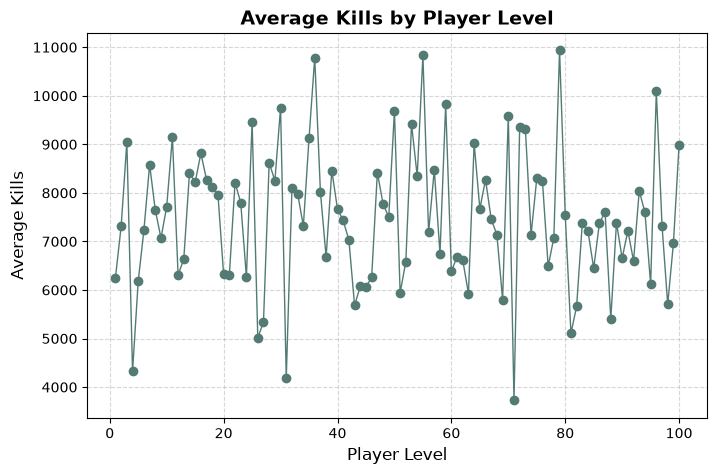

In [5]:
level_kills = bgmi.groupby("Level")["Kills"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    level_kills.index,
    level_kills.values,
    marker="o",
    color="#537B74",
    linewidth=1
)

plt.title("Average Kills by Player Level", fontsize=14, fontweight="bold")
plt.xlabel("Player Level", fontsize=12)
plt.ylabel("Average Kills", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Observation

The line chart shows how the average number of kills changes across different player levels.

### Insight

The chart helps us observe whether average kills tend to increase or decrease as player level changes.

### Which rank has the highest number of players?

**Chart Type: Bar Chart**

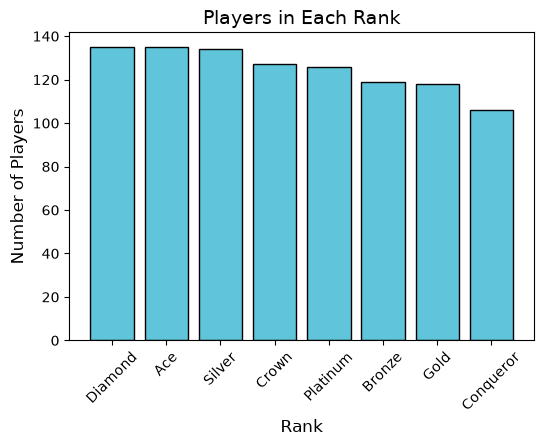

In [22]:


rank = bgmi["Rank"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    rank.index,
    rank.values,
    color="#60c5db",
    edgecolor="black",
    width= 0.8
)

plt.title("Players in Each Rank", fontsize=14, color="black")
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)

plt.xticks(rotation=45)
plt.show()

### Observation

The bar chart compares the number of players in each rank. The tallest bar represents the rank with the highest number of players.

### Insight

The chart makes it easy to compare the distribution of players across different ranks.

### How are Premium Pass users distributed?

**Chart Type: Pie Chart**

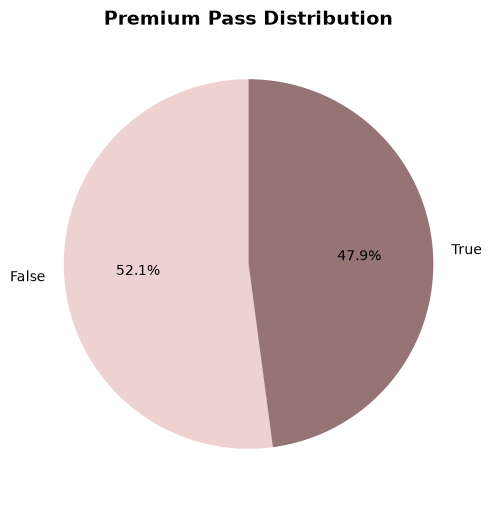

In [27]:
premium = bgmi["Premium_Pass"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    premium.values,
    labels=premium.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#EED1D1", "#977474"]
)

plt.title("Premium Pass Distribution", fontsize=14, fontweight="bold")

plt.show()

### Observation

The pie chart shows the proportion of players who have Premium Pass and those who do not.

### Insight

The chart gives a quick view of the Premium Pass distribution among players.

### How is the KD ratio distributed among players?

**Chart Type: Histogram**

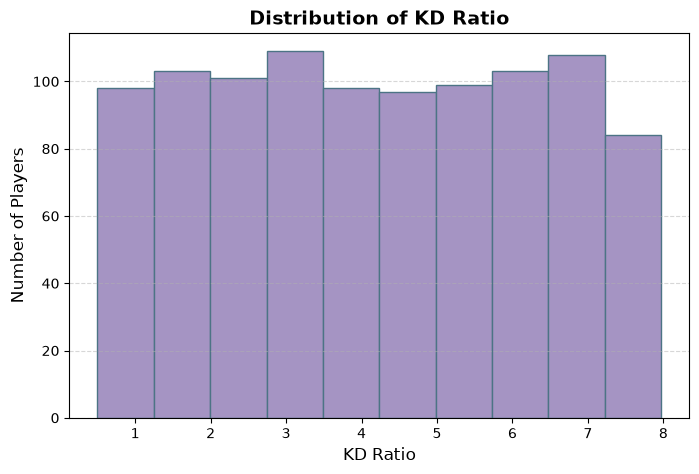

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    bgmi["KD"],
    bins=10,
    color="#A594C3",
    edgecolor="#4C7485"
)

plt.title("Distribution of KD Ratio", fontsize=14, fontweight="bold")
plt.xlabel("KD Ratio", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

The histogram shows how players are distributed across different KD ratio ranges.

### Insight

The distribution helps us understand the range in which most players' KD ratios fall.

### Is there any relationship between Matches Played and Wins?

**Chart Type: Scatter Plot**

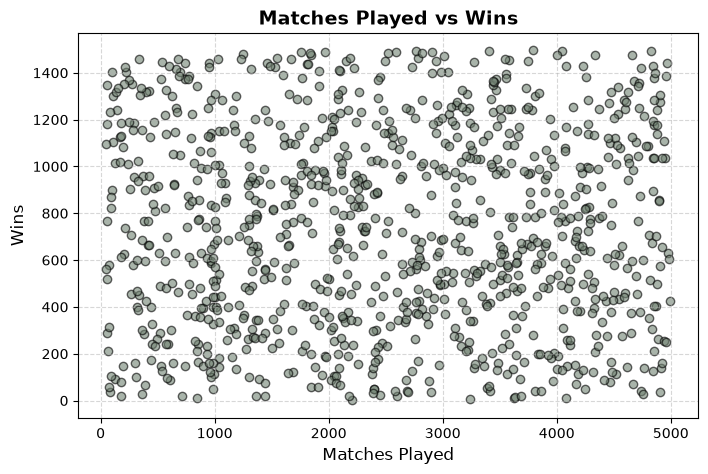

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    bgmi["Matches_Played"],
    bgmi["Wins"],
    color="#718272",
    edgecolor="black",
    alpha=0.6
)

plt.title("Matches Played vs Wins", fontsize=14, fontweight="bold")
plt.xlabel("Matches Played", fontsize=12)
plt.ylabel("Wins", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Observation

The scatter plot shows the relationship between the number of matches played and wins.

### Insight

The plot helps us visually check whether players with more matches played tend to have more wins.

### Which are the Top 10 players with the highest number of kills?

**Chart Type: Horizontal Bar Chart**

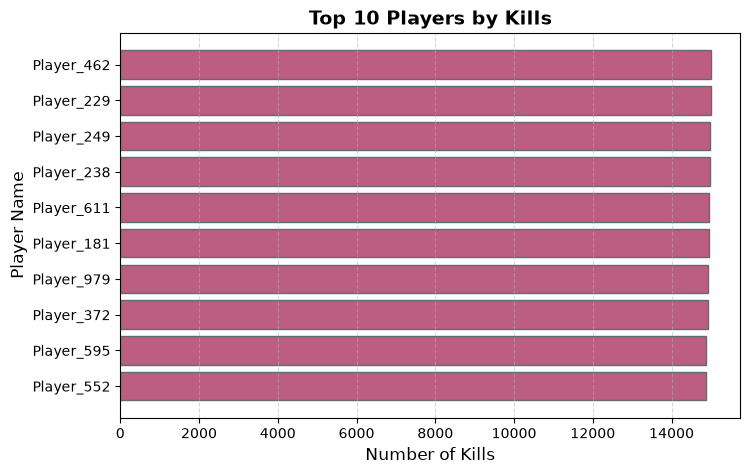

In [43]:
top_kills = bgmi[["Player_Name", "Kills"]].sort_values(
    by="Kills",
    ascending=False
).head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_kills["Player_Name"],
    top_kills["Kills"],
    color="#BC5E80",
    edgecolor="#626B6F"
)

plt.title("Top 10 Players by Kills", fontsize=14, fontweight="bold")
plt.xlabel("Number of Kills", fontsize=12)
plt.ylabel("Player Name", fontsize=12)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

### Observation

The horizontal bar chart displays the 10 players with the highest number of kills.

### Insight

The chart makes it easy to compare the kill performance of the top players.

## Phase 4 Summary

In this phase, different charts were used to visualize the BGMI player data. A bar chart was used to compare players across ranks, a pie chart was used to show Premium Pass distribution, and a histogram was used to understand the distribution of KD ratios. A scatter plot was used to study the relationship between matches played and wins, while a horizontal bar chart was used to compare the Top 10 players with the highest kills.

These visualizations make the results easier to compare and help us identify useful patterns in the dataset.

# 📌 Final Findings & Insights

The BGMI dataset was explored, cleaned, analyzed, and visualized to understand different aspects of player performance. The analysis provided useful information about kills, damage, ranks, maps, KD ratio, matches played, wins, and Premium Pass usage.

The main findings from the project are:

- The player with the highest number of kills was identified from the dataset.
- The Top 10 players with the highest kills were compared using a horizontal bar chart.
- The average kills and average damage of the players were calculated.
- The rank with the highest number of players and the most played map were identified.
- Premium Pass usage was visualized to understand its distribution among players.
- The KD ratio distribution was analyzed using a histogram.
- The relationship between Matches Played and Wins was examined using a scatter plot.
- Average kills across different player levels were visualized using a line chart.
- The Player_Number feature was extracted from Player_Name and converted into a suitable numerical data type.

These findings helped us understand the player data and identify useful patterns through both numerical analysis and visualizations.